In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")


In [13]:
DATA_PATH = "../data/processed/flights_sample.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df = df.rename(columns={
    "OP_CARRIER": "AIRLINE",
    "ORIGIN": "ORIGIN_AIRPORT",
    "DEST": "DESTINATION_AIRPORT",
    "CRS_DEP_TIME": "SCHEDULED_DEPARTURE"
})

df.head()


(200000, 28)


,FL_DATE,AIRLINE,OP_CARRIER_FL_NUM,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEP_TIME,DEP_DELAY,TAXI_OUT,WHEELS_OFF,...,CRS_ELAPSED_TIME,ACTUAL_ELAPSED_TIME,AIR_TIME,DISTANCE,CARRIER_DELAY,WEATHER_DELAY,NAS_DELAY,SECURITY_DELAY,LATE_AIRCRAFT_DELAY,Unnamed: 27
0,2018-07-16,EV,4371,HSV,IAH,646,643.0,-3.0,13.0,656.0,...,112.0,106.0,86.0,595.0,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-10-08,UA,1597,SFO,LAX,2000,1955.0,-5.0,20.0,2015.0,...,98.0,87.0,51.0,337.0,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-06-05,AA,356,CLT,ORD,1130,1138.0,8.0,25.0,1203.0,...,136.0,131.0,94.0,599.0,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-09-06,AA,958,AUS,LAX,1848,1838.0,-10.0,19.0,1857.0,...,194.0,194.0,162.0,1242.0,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-10-22,DL,1790,ATL,SAT,1153,1150.0,-3.0,8.0,1158.0,...,154.0,136.0,126.0,874.0,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   FL_DATE              200000 non-null  object 
 1   AIRLINE              200000 non-null  object 
 2   OP_CARRIER_FL_NUM    200000 non-null  int64  
 3   ORIGIN_AIRPORT       200000 non-null  object 
 4   DESTINATION_AIRPORT  200000 non-null  object 
 5   SCHEDULED_DEPARTURE  200000 non-null  int64  
 6   DEP_TIME             196872 non-null  float64
 7   DEP_DELAY            196742 non-null  float64
 8   TAXI_OUT             196794 non-null  float64
 9   WHEELS_OFF           196794 non-null  float64
 10  WHEELS_ON            196699 non-null  float64
 11  TAXI_IN              196699 non-null  float64
 12  CRS_ARR_TIME         200000 non-null  int64  
 13  ARR_TIME             196699 non-null  float64
 14  ARR_DELAY            196212 non-null  float64
 15  CANCELLED        

In [15]:
df["DEP_DELAY"].describe()


count    196742.000000
mean          9.974001
std          44.399564
min         -50.000000
25%          -5.000000
50%          -2.000000
75%           7.000000
max        1502.000000
Name: DEP_DELAY, dtype: float64

In [16]:
df["IS_DELAYED"] = (df["DEP_DELAY"] > 15).astype(int)
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"])
df["DAY_OF_WEEK"] = df["FL_DATE"].dt.dayofweek + 1


df["IS_DELAYED"].value_counts(normalize=True)


IS_DELAYED
0    0.82422
1    0.17578
Name: proportion, dtype: float64

In [17]:
df["CANCELLED"].value_counts(normalize=True)
pd.crosstab(df["IS_DELAYED"], df["CANCELLED"], normalize="index")


CANCELLED,0.0,1.0
IS_DELAYED,,
0,0.980739,0.019261
1,0.998521,0.001479


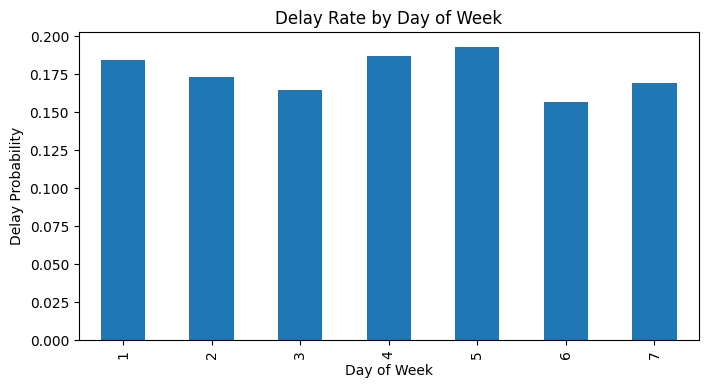

In [18]:
delay_by_day = df.groupby("DAY_OF_WEEK")["IS_DELAYED"].mean()

delay_by_day.plot(kind="bar", figsize=(8,4))
plt.title("Delay Rate by Day of Week")
plt.ylabel("Delay Probability")
plt.xlabel("Day of Week")
plt.show()


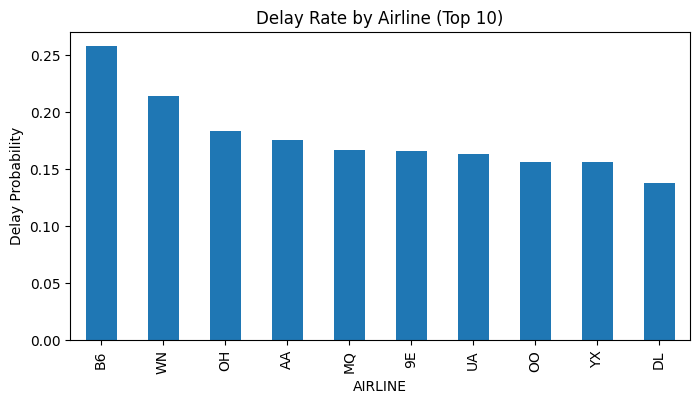

In [19]:
top_airlines = df["AIRLINE"].value_counts().head(10).index

airline_delay = (
    df[df["AIRLINE"].isin(top_airlines)]
    .groupby("AIRLINE")["IS_DELAYED"]
    .mean()
    .sort_values(ascending=False)
)

airline_delay.plot(kind="bar", figsize=(8,4))
plt.title("Delay Rate by Airline (Top 10)")
plt.ylabel("Delay Probability")
plt.show()


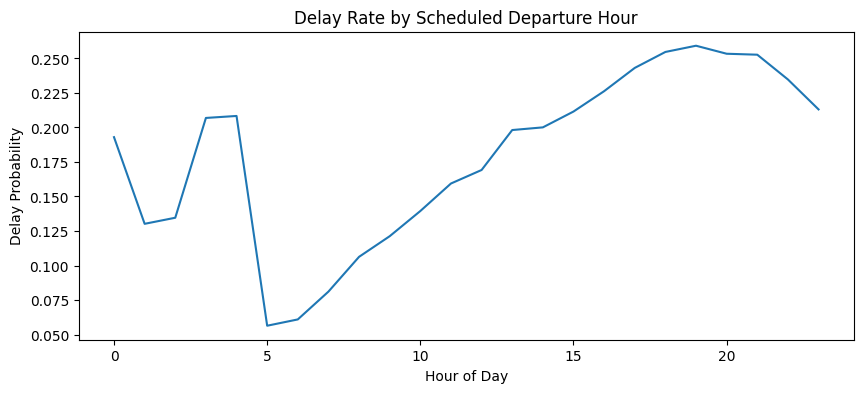

In [20]:
df["DEP_HOUR"] = df["SCHEDULED_DEPARTURE"] // 100

hourly_delay = df.groupby("DEP_HOUR")["IS_DELAYED"].mean()

hourly_delay.plot(figsize=(10,4))
plt.title("Delay Rate by Scheduled Departure Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Delay Probability")
plt.show()
